In [1]:
import tensorflow as tf
from tensorflow import keras


# Güvenli import (Keras 3/TF sürüm farklarını önler)
try:
    from tensorflow.keras.utils import to_categorical
except Exception:
    from keras.utils import to_categorical  # yüklü sürüme göre fallback

import numpy as np

# 1) Veri
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = (x_train.astype("float32") / 255.0)
x_test  = (x_test.astype("float32") / 255.0)

# y_train shape: (50000, 1) -> one-hot
y_train = to_categorical(y_train.reshape(-1), num_classes=10)
y_test  = to_categorical(y_test.reshape(-1),  num_classes=10)

# 2) Model
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 3) Eğitim
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,            # bellek dostu
    validation_data=(x_test, y_test),
    verbose=2
)

# 4) Değerlendirme
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", float(test_acc))



C:\Users\sena\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
782/782 - 19s - 24ms/step - accuracy: 0.4257 - loss: 1.5718 - val_accuracy: 0.5433 - val_loss: 1.2720
Epoch 2/15
782/782 - 17s - 22ms/step - accuracy: 0.5702 - loss: 1.2058 - val_accuracy: 0.5940 - val_loss: 1.1370
Epoch 3/15
782/782 - 18s - 22ms/step - accuracy: 0.6287 - loss: 1.0577 - val_accuracy: 0.6390 - val_loss: 1.0182
Epoch 4/15
782/782 - 16s - 20ms/step - accuracy: 0.6658 - loss: 0.9585 - val_accuracy: 0.6502 - val_loss: 1.0062
Epoch 5/15
782/782 - 18s - 23ms/step - accuracy: 0.6906 - loss: 0.8895 - val_accuracy: 0.6473 - val_loss: 1.0322
Epoch 6/15
782/782 - 15s - 19ms/step - accuracy: 0.7097 - loss: 0.8273 - val_accuracy: 0.6956 - val_loss: 0.8748
Epoch 7/15
782/782 - 17s - 22ms/step - accuracy: 0.7268 - loss: 0.7848 - val_accuracy: 0.7036 - val_loss: 0.8610
Epoch 8/15
782/782 - 16s - 20ms/step - accuracy: 0.7423 - loss: 0.7419 - val_accuracy: 0.6895 - val_loss: 0.9108
Epoch 9/15
782/782 - 16s - 20ms/step - accuracy: 0.7523 - loss: 0.7077 - val_accuracy: 0.7103 - 

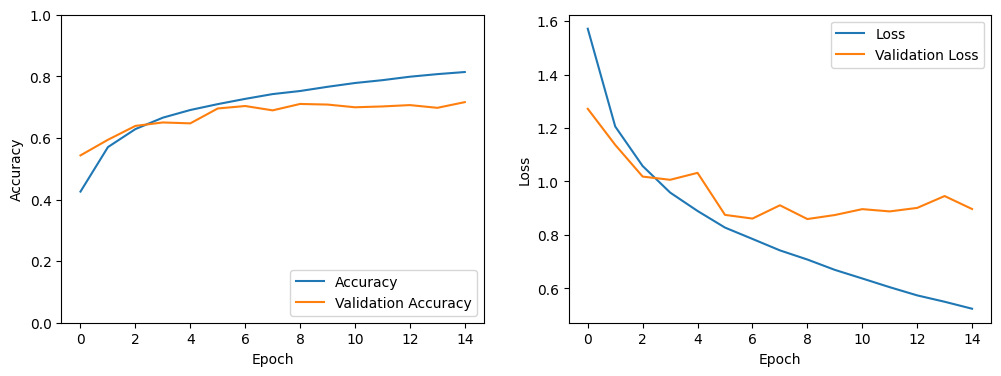

In [3]:
 import matplotlib.pyplot as plt
 plt.figure(figsize=(12, 4))
 plt.subplot(1, 2, 1)
 plt.plot(history.history['accuracy'], label='Accuracy')
 plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
 plt.xlabel('Epoch')
 plt.ylabel('Accuracy')
 plt.ylim([0, 1])
 plt.legend(loc='lower right')
 plt.subplot(1, 2, 2)
 plt.plot(history.history['loss'], label='Loss')
 plt.plot(history.history['val_loss'], label='Validation Loss')
 plt.xlabel('Epoch')
 plt.ylabel('Loss')
 plt.legend(loc='upper right')
 plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


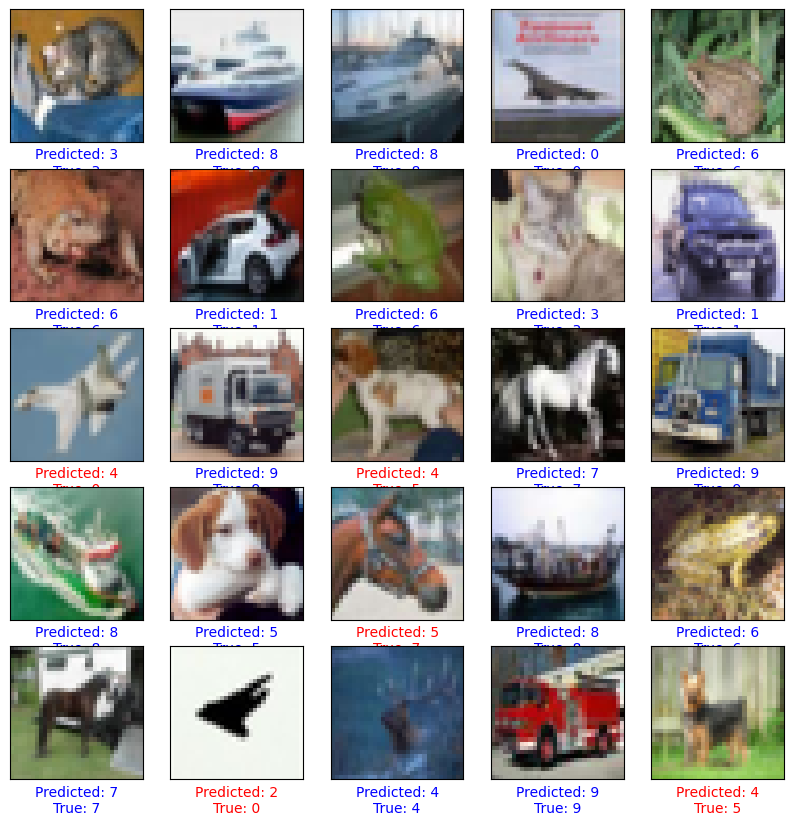

In [5]:
predictions = model.predict(x_test) 
plt.figure(figsize=(10, 10)) 
for i in range(25): 
 plt.subplot(5, 5, i+1) 
 plt.xticks([]) 
 plt.yticks([]) 
 plt.grid(False) 
 plt.imshow(x_test[i], cmap=plt.cm.binary) 
 predicted_label = predictions[i].argmax() 
 true_label = y_test[i].argmax() 
 if predicted_label == true_label: 
  color = 'blue' 
 else: 
  color = 'red' 
 plt.xlabel(f'Predicted: {predicted_label}\nTrue: {true_label}', color=color) 
plt.show()
